<a href="https://colab.research.google.com/github/negarmajma/Customer_churn_prediction_with_dif_Algorithm_and_GeneticAlgo_Selection/blob/main/RNS_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [ ]:
file_path_Brain="Sensor_Brain_Input.txt"
file_path_Body = "Sensor_Body_Input.txt"

In [ ]:
# ---  تعریف تابع فازی سازی ورودی ها ---
def fuzzify_sensors(values,plot_mfs):
    # values = [ECoG, HFOs, IEDs, SP, BRFB]
    fuzzified = []

    # 1. ECoG [0,100]
    x_ecog = np.linspace(0, 100, 101)
    ecog_low = fuzz.trapmf(x_ecog, [0, 0, 25, 50])
    ecog_med = fuzz.trimf(x_ecog, [25, 50, 75])
    ecog_high = fuzz.trapmf(x_ecog, [50, 75, 100, 100])
    fuzzified.append([
        fuzz.interp_membership(x_ecog, ecog_low, values[0]),
        fuzz.interp_membership(x_ecog, ecog_med, values[0]),
        fuzz.interp_membership(x_ecog, ecog_high, values[0])
    ])

    # 2. HFOs [0,300]
    x_hfo = np.linspace(0, 300, 301)
    hfo_low = fuzz.trapmf(x_hfo, [0, 0, 50, 100])
    hfo_med = fuzz.trimf(x_hfo, [50, 100, 200])
    hfo_high = fuzz.trapmf(x_hfo, [200, 250, 300, 300])
    fuzzified.append([
        fuzz.interp_membership(x_hfo, hfo_low, values[1]),
        fuzz.interp_membership(x_hfo, hfo_med, values[1]),
        fuzz.interp_membership(x_hfo, hfo_high, values[1])
    ])

    # 3. IEDs [0,20]
    x_ied = np.linspace(0, 20, 201)
    ied_low = fuzz.trapmf(x_ied, [0, 0, 3, 6])
    ied_med = fuzz.trimf(x_ied, [3, 6, 10])
    ied_high = fuzz.trapmf(x_ied, [10, 15, 20, 20])
    fuzzified.append([
        fuzz.interp_membership(x_ied, ied_low, values[2]),
        fuzz.interp_membership(x_ied, ied_med, values[2]),
        fuzz.interp_membership(x_ied, ied_high, values[2])
    ])

    # 4. SP [0,1]
    x_sp = np.linspace(0, 1, 101)
    sp_low = fuzz.trapmf(x_sp, [0, 0, 0.05, 0.1])
    sp_med = fuzz.trimf(x_sp, [0.05, 0.1, 0.15])
    sp_high = fuzz.trapmf(x_sp, [0.1, 0.15, 1.0, 1.0])
    fuzzified.append([
        fuzz.interp_membership(x_sp, sp_low, values[3]),
        fuzz.interp_membership(x_sp, sp_med, values[3]),
        fuzz.interp_membership(x_sp, sp_high, values[3])
    ])

    # 5. BRFB [0,50]
    x_brfb = np.linspace(0, 50, 101)
    brfb_low = fuzz.trapmf(x_brfb, [0, 0, 10, 20])
    brfb_med = fuzz.trimf(x_brfb, [10, 20, 30])
    brfb_high = fuzz.trapmf(x_brfb, [30, 40, 50, 50])
    fuzzified.append([
        fuzz.interp_membership(x_brfb, brfb_low, values[4]),
        fuzz.interp_membership(x_brfb, brfb_med, values[4]),
        fuzz.interp_membership(x_brfb, brfb_high, values[4])
    ])


    if plot_mfs==True:
    # ---- رسم توابع عضویت ----

      fig, axes = plt.subplots(5, 1, figsize=(8, 15))

      axes[0].plot(x_ecog, ecog_low, 'b', label="Low")
      axes[0].plot(x_ecog, ecog_med, 'g', label="Medium")
      axes[0].plot(x_ecog, ecog_high, 'r', label="High")
      axes[0].set_title("ECoG Membership Functions")
      axes[0].legend()

      axes[1].plot(x_hfo, hfo_low, 'b', label="Low")
      axes[1].plot(x_hfo, hfo_med, 'g', label="Medium")
      axes[1].plot(x_hfo, hfo_high, 'r', label="High")
      axes[1].set_title("HFOs Membership Functions")
      axes[1].legend()

      axes[2].plot(x_ied, ied_low, 'b', label="Low")
      axes[2].plot(x_ied, ied_med, 'g', label="Medium")
      axes[2].plot(x_ied, ied_high, 'r', label="High")
      axes[2].set_title("IEDs Membership Functions")
      axes[2].legend()

      axes[3].plot(x_sp, sp_low, 'b', label="Low")
      axes[3].plot(x_sp, sp_med, 'g', label="Medium")
      axes[3].plot(x_sp, sp_high, 'r', label="High")
      axes[3].set_title("SP Membership Functions")
      axes[3].legend()

      axes[4].plot(x_brfb, brfb_low, 'b', label="Low")
      axes[4].plot(x_brfb, brfb_med, 'g', label="Medium")
      axes[4].plot(x_brfb, brfb_high, 'r', label="High")
      axes[4].set_title("BRFB Membership Functions")
      axes[4].legend()

      plt.tight_layout()
      plt.show()

    return np.array(fuzzified)


In [ ]:
# تعریف توابع عضویت خروجی روی بازه [0,1]
x_out = np.linspace(0, 1, 1001)  # دقت بالاتر برای دیفازی

# توابع عضویت مثلثی خروجی
normal_mf = fuzz.trapmf(x_out, [0, 0, 0.3, 0.55])
probable_epileptic_mf = fuzz.trimf(x_out, [0.3, 0.55, 0.75])
seizure_onset_mf = fuzz.trapmf(x_out, [0.55, 0.75, 1.0, 1.0])


In [ ]:
# --- قوانین 17 گانه ---
ruleList = [
    [1,2,1,2,1,2,1,1],
    [1,2,1,3,1,2,1,1],
    [1,2,3,2,1,2,1,1],
    [1,2,3,3,1,3,1,1],
    [2,2,1,2,1,2,1,1],
    [2,2,1,3,1,2,1,1],
    [2,2,3,2,1,2,1,1],
    [2,2,3,3,1,3,1,1],
    [3,2,1,1,1,2,1,1],
    [3,2,1,2,1,2,1,1],
    [3,2,1,3,1,2,1,1],
    [3,2,3,2,1,3,1,1],
    [3,3,1,2,1,3,1,1],
    [3,3,1,3,1,3,1,1],
    [3,3,3,2,1,3,1,1],
    [3,3,3,3,1,3,1,1],
    [3,3,3,3,3,3,1,1],
    [0,0,0,1,0,1,1,1],
    [0,1,3,3,0,2,1,1],
    [3,2,0,0,3,3,1,1]
]

In [ ]:
output_labels = {
    1: "Normal",
    2: "Probable_Epileptic",
    3: "Seizure_Detection",
}

In [ ]:
# --- تابع واحد استنتاج ---
def inference_engine(fuzzy_inputs):
    """
    fuzzy_inputs: آرایه 5x3 درجه عضویت ورودی‌ها [Low, Med, High]
    خروجی: dict شدت فعال شدن هر کلاس خروجی
    """
    aggregated = {key: 0.0 for key in output_labels.keys()}

    for rule in ruleList:
        inputs = rule[:5]
        output = rule[5]
        weight = rule[6]
        op = rule[7]

        memberships = [fuzzy_inputs[i][inputs[i]-1] for i in range(5)]

        if op == 1:  # AND
            activation = min(memberships)
        else:        # OR
            activation = max(memberships)

        activation *= weight

        # تجمیع: هر خروجی بیشترین شدت فعال شده را می‌گیرد
        aggregated[output] = max(aggregated[output], activation)

    return aggregated

In [ ]:
def defuzzify(fuzzy_result):
    """
    fuzzy_result: dict با شدت هر کلاس خروجی (0 تا 1)
                  کلیدها: 1=Normal, 2=Probable_Epileptic, 3=Seizure_Detection
    خروجی: عدد دی‌فازی‌شده روی بازه [0,1]
    """

    agg_mf = np.fmax(
        np.fmax(
            fuzzy_result.get(1, 0) * normal_mf,
            fuzzy_result.get(2, 0) * probable_epileptic_mf
        ),
        fuzzy_result.get(3, 0) * seizure_onset_mf
    )

    if np.sum(agg_mf) == 0:
        return 0.0  # پیش‌فرض یا جلوگیری از خطا

    return fuzz.defuzz(x_out, agg_mf, 'centroid')


In [ ]:
def fuzzy_label(defuzz_value):
  """
  انتخاب خروجی بر اساس بیشترین شدت فعال شدن
  """
  if not fuzzy_result:
      return "Normal"
  best_key = max(fuzzy_result, key=fuzzy_result.get)
  return output_labels[best_key]

In [ ]:
def read_sensor_body_input(file_path, line_number):
    """
    خواندن داده‌های بدنی از فایل
    هر خط: x_AC x_HR x_BP x_tem
    خروجی: لیست تاپل‌ها [(x_AC, x_HR, x_BP, x_tem), ...]
    """

    with open(file_path, 'r') as f:
        for i,line in enumerate(f, start=1):
            if i==line_number:
                parts = line.strip().split()
                if len(parts) != 4:
                    return None
                x_AC = parts[0]              # 'R', 'N', 'H'
                x_HR = float(parts[1])      # ضربان قلب
                x_BP = float(parts[2])      # فشار خون
                x_tem = float(parts[3])     # دمای بدن
                return (x_AC, x_HR, x_BP, x_tem)
    return None # خط پیدا نشد

In [ ]:
def Calculate_Reward(x_AC, x_HR, x_BP, x_tem):
    """
    محاسبه پاداش R یا جریمه P بر اساس شرایط داده شده
    """
    # شرط R
    if ((x_AC=='R' and 60.0 < x_HR <= 100.0) or
        (x_AC=='N' and 100.0 <= x_HR <= 140.0) or
        (x_AC=='H' and 140.0 <= x_HR <= 180.0) or
        (36.1 <= x_tem < 37.5) or
        (90.0 <= x_BP <= 120.0)):
        return 'R'

    # شرط P
    if ((x_HR < 50.0 and x_AC=='R' and x_HR > 100.0) or
        (x_tem > 37.5) or
        (x_BP > 120.0)):
        return 'P'

    return 'None'  # اگر هیچکدام برقرار نبود

RUN


================ Senario 1 ================


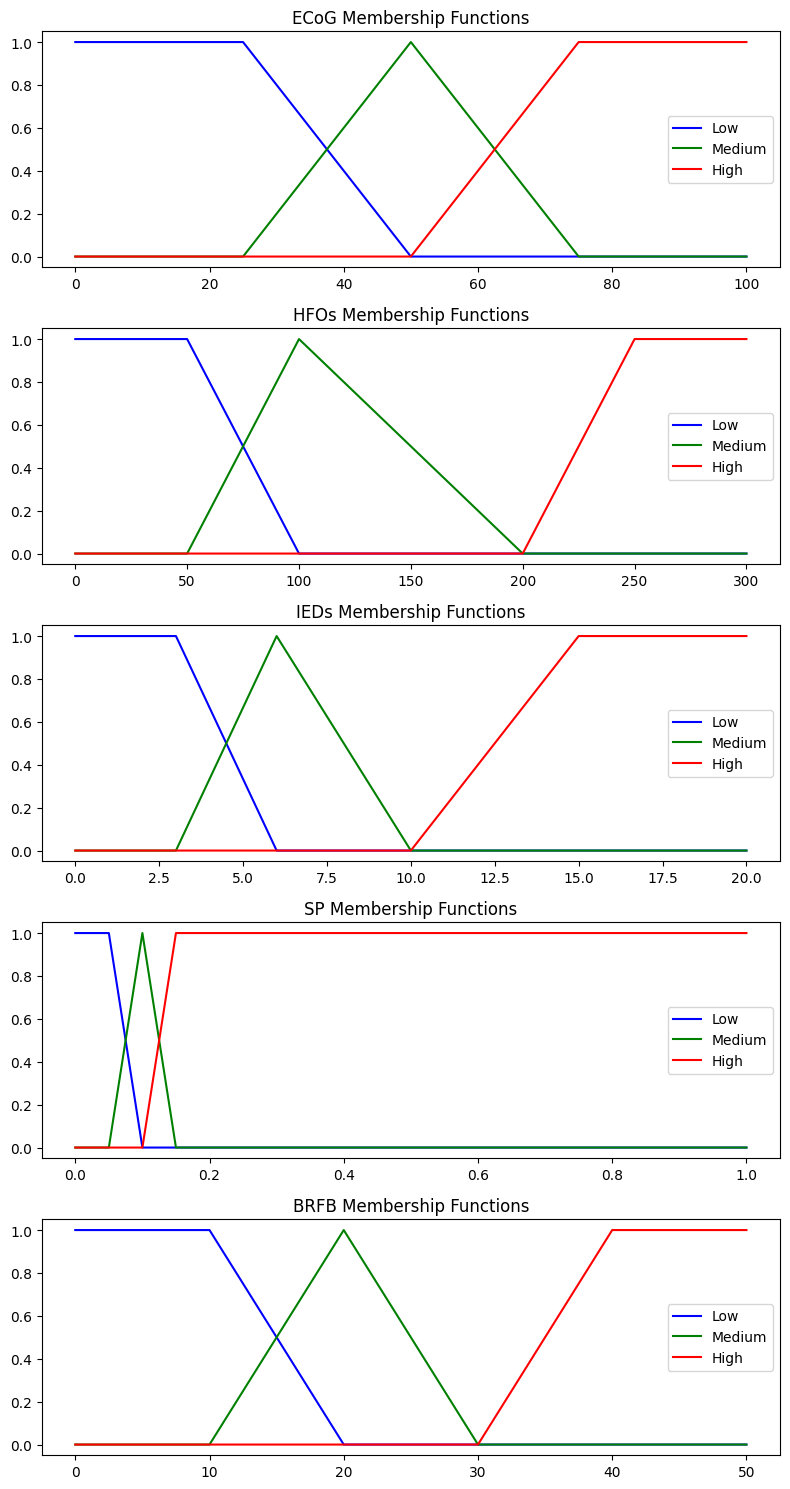

Sensor Values: [95.0, 285.0, 18.0, 0.18, 44.0]
Fuzzy Memberships:
 [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Fuzzy Output (membership per class):
Normal: 0.000
Probable_Epileptic: 0.000
Seizure_Detection: 1.000
Defuzzified output (0-1): 0.8202380952380952
Defuzzufied output Label: Seizure_Detection
********Action_To Body: Seizure_Detection
********Sate_To_Body: Monitoring
****ٌWait for Stimulation on Body*****
Second: 1
Second: 2
****Get Reward from Body*****
Line 1: AC='N', HR=130.0, BP=150.0, Temp=38.5 => Reward: P
********Sate_To_Body: Stimulation
********Final Sate_To_Body: Stimulation

================ Senario 2 ================
Sensor Values: [40.0, 80.0, 5.0, 0.0106, 18.0]
Fuzzy Memberships:
 [[0.4        0.6        0.        ]
 [0.4        0.6        0.        ]
 [0.33333333 0.66666667 0.        ]
 [1.         0.         0.        ]
 [0.2        0.8        0.        ]]
Fuzzy Output (membership per class):
Normal: 0.000
Probable_Epileptic: 0.000
Seizure_Detect

In [ ]:
"""RUN in loop"""
line_number=0
# لیست برای ذخیره وضعیت اولیه و نهایی هر سناریو
initial_states = []
final_states = []
defuzzified_scores = []  # اضافه شده برای ذخیره مقادیر دی‌فازی‌شده


# --- اجرای حلقه برای 10 خط ورودی مغز ---
for line_idx in range(1, 11):   # ده بار تکرار
    print("\n================ Senario", line_idx, "================")

    # خواندن خط line_idx از فایل Brain
    with open(file_path_Brain, "r") as f:
        lines = f.readlines()
    if line_idx > len(lines):
        print("خط کافی در فایل Brain وجود ندارد.")
        break

    line = lines[line_idx-1].strip()
    sensor_values = list(map(float, line.split()))

    # اجرای فازی‌سازی
    fuzzy_outputs = fuzzify_sensors(sensor_values,True if line_idx==1 else False)

    print("Sensor Values:", sensor_values)
    print("Fuzzy Memberships:\n", fuzzy_outputs)

    # فراخوانی تابع استنتاج
    fuzzy_result = inference_engine(fuzzy_outputs)

    print("Fuzzy Output (membership per class):")
    for k,v in fuzzy_result.items():
        print(f"{output_labels[k]}: {v:.3f}")

    # دی‌فازی‌سازی
    numeric_output = defuzzify(fuzzy_result)
    defuzzified_scores.append(numeric_output)  # ذخیره برای ROC
    print("Defuzzified output (0-1):", numeric_output)

    # برچسب معادل
    text_output = fuzzy_label(numeric_output)
    print("Defuzzufied output Label:", text_output)

    ######### خروجی سیستم و اعمال به بدن
    Action_To_Body = text_output
    print("********Action_To Body:", Action_To_Body)

    if Action_To_Body == 'Seizure_onset':
        Sate_To_Body = 'Stimulation'
        print("********Sate_To_Body:", Sate_To_Body)
    else:
        Sate_To_Body = 'Monitoring'
        print("********Sate_To_Body:", Sate_To_Body)

    # ذخیره وضعیت اولیه
    initial_state = Sate_To_Body
    initial_states.append(initial_state)

    if Sate_To_Body == 'Stimulation':
      # تکرار یادگیری به مدت 3 بار
      for repeat in range(1,4):
        # --- دریافت  سنسورهای بدنی و محاسبه پاداش ---
        # شمارش از 1 تا 100 ثانیه
        print("****ٌWait for Stimulation on Body*****")
        for t in range(1, 3):  # تغییر به مقدار بیشتر
          print(f"Second: {t}")
          time.sleep(1)  # یک ثانیه مکث

        print("****Get Reward from Body*****")
        line_number=repeat # شماره خط مورد نظر
        sensor_values = read_sensor_body_input(file_path_Body, line_number)
        if sensor_values is not None:
          x_AC, x_HR, x_BP, x_tem=sensor_values
          reward = Calculate_Reward(x_AC, x_HR, x_BP, x_tem)
          print(f"Line {line_number}: AC={x_AC}, HR={x_HR}, BP={x_BP}, Temp={x_tem} => Reward: {reward}")
        else:
          print(f"خط {line_number} وجود ندارد یا فرمت اشتباه است.")
        #-----انتخاب state بعدی
        if (Sate_To_Body=="Stimulation" and reward=="P"):
          Sate_To_Body="Stimulation"
          print("********Sate_To_Body:",Sate_To_Body)
        else: #reward=="R"
          Sate_To_Body="Monitoring"
          print("Back to get Brain data")
          break
    elif Sate_To_Body == 'Monitoring': # یک بار پارامترهای بدنی بررسی شود
       # تکرار یادگیری به مدت 1 بار
       # --- دریافت  سنسورهای بدنی و محاسبه پاداش ---
       # شمارش از 1 تا 100 ثانیه
      print("****ٌWait for Stimulation on Body*****")
      for t in range(1, 3):  # تغییر به مقدار بیشتر
        print(f"Second: {t}")
        time.sleep(1)  # یک ثانیه مکث

      print("****Get Reward from Body*****")
      line_number=line_number+1 # شماره خط مورد نظر
      sensor_values = read_sensor_body_input(file_path_Body, line_number)
      if sensor_values is not None:
        x_AC, x_HR, x_BP, x_tem=sensor_values
        reward = Calculate_Reward(x_AC, x_HR, x_BP, x_tem)
        print(f"Line {line_number}: AC={x_AC}, HR={x_HR}, BP={x_BP}, Temp={x_tem} => Reward: {reward}")
      else:
        print(f"خط {line_number} وجود ندارد یا فرمت اشتباه است.")
        #-----انتخاب state بعدی
      if (reward=="P"):
          Sate_To_Body="Stimulation"
          print("********Sate_To_Body:",Sate_To_Body)
      else: #reward=="R"
          Sate_To_Body="Monitoring"
          print("Back to get Brain data")

    print("********Final Sate_To_Body:", Sate_To_Body)
    # ذخیره وضعیت نهایی
    final_states.append(Sate_To_Body)



================ Initial vs Final Evaluation Summary ================
Total Scenarios: 10
Number of scenarios where Initial and Final Sate_To_Body are the SAME: 3
Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: 7
Correction Rate: 0.70
Accuracy: 0.30
Precision (for Stimulation): 0.00
Recall (for Stimulation): 0.00
F1-Score (for Stimulation): 0.00

Confusion Matrix (Initial vs Final):
                Predicted Stimulation | Predicted Monitoring/No_Action
Actual Stimulation | 0                  | 7
Actual Monitoring/No_Action | 0                  | 3

================ Final vs Ground Truth Evaluation Summary ================
Accuracy (Final vs Ground Truth): 0.20
Precision (Final vs Ground Truth): 0.14
Recall (Final vs Ground Truth): 0.33
F1-Score (Final vs Ground Truth): 0.20
AUC (Final vs Ground Truth): 0.36

Confusion Matrix (Final vs Ground Truth):
                Predicted Stimulation | Predicted Monitoring/No_Action
Actual Stimulation | 1                  | 

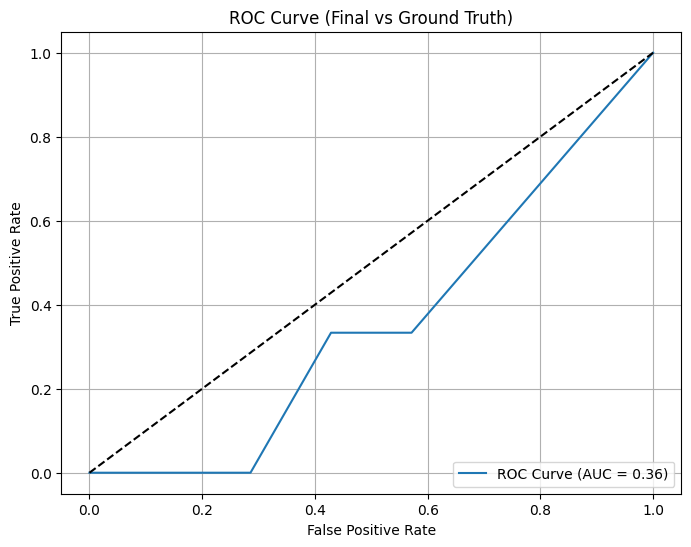

In [ ]:
# کد اضافه شده برای شمارش و ارزیابی
total_scenarios = len(initial_states)
same_count = 0
different_count = 0

# برای محاسبه معیارها (مانند Confusion Matrix برای دو کلاس: Stimulation=Positive, Monitoring/No_Action=Negative)
true_positives = 0  # Initial Stimulation و Final Stimulation
true_negatives = 0  # Initial Monitoring/No_Action و Final Monitoring/No_Action
false_positives = 0 # Initial Stimulation اما Final Monitoring/No_Action
false_negatives = 0 # Initial Monitoring/No_Action اما Final Stimulation

for i in range(total_scenarios):
    init = initial_states[i]
    fin = final_states[i]

    if init == fin:
        same_count += 1
        if init == 'Stimulation':
            true_positives += 1
        else:
            true_negatives += 1
    else:
        different_count += 1
        if init == 'Stimulation':
            false_positives += 1
        else:
            false_negatives += 1

# محاسبه Correction Rate
correction_rate = different_count / total_scenarios if total_scenarios > 0 else 0

# محاسبه معیارهای ارزیابی
accuracy_result = (true_positives + true_negatives) / total_scenarios if total_scenarios > 0 else 0
precision_result = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall_result = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_result = 2 * (precision_result * recall_result) / (precision_result + recall_result) if (precision_result + recall_result) > 0 else 0

print("\n================ Initial vs Final Evaluation Summary ================")
print(f"Total Scenarios: {total_scenarios}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are the SAME: {same_count}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: {different_count}")
print(f"Correction Rate: {correction_rate:.2f}")
print(f"Accuracy: {accuracy_result:.2f}")
print(f"Precision (for Stimulation): {precision_result:.2f}")
print(f"Recall (for Stimulation): {recall_result:.2f}")
print(f"F1-Score (for Stimulation): {f1_result:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Initial vs Final):")
print("                Predicted Stimulation | Predicted Monitoring/No_Action")
print(f"Actual Stimulation | {true_positives}                  | {false_negatives}")
print(f"Actual Monitoring/No_Action | {false_positives}                  | {true_negatives}")

# کد اضافه شده برای خواندن Ground_truth و ارزیابی بر اساس آن
def read_ground_truth(file_path):
    ground_truth = []
    with open(file_path, 'r') as f:
        for line in f:
            label = line.strip()
            ground_truth.append(label)
    return ground_truth

file_path_ground_truth = "Ground_truth.txt"  # نام فایل Ground_truth
ground_truth_labels = read_ground_truth(file_path_ground_truth)

if len(ground_truth_labels) != total_scenarios:
    print("تعداد خطوط Ground_truth با تعداد سناریوها همخوانی ندارد.")
else:
    # تبدیل برچسب‌ها به باینری برای ارزیابی
    y_true_ground = [1 if label == "Stimulation" else 0 for label in ground_truth_labels]
    y_pred_final = [1 if state == "Stimulation" else 0 for state in final_states]
    y_pred_initial = [1 if state == "Stimulation" else 0 for state in initial_states]

    # محاسبه معیارها برای Final vs Ground Truth
    accuracy_ground_val = accuracy_score(y_true_ground, y_pred_final)
    precision_ground_val = precision_score(y_true_ground, y_pred_final, zero_division=0)
    recall_ground_val = recall_score(y_true_ground, y_pred_final, zero_division=0)
    f1_ground_val = f1_score(y_true_ground, y_pred_final, zero_division=0)
    auc_ground_val = roc_auc_score(y_true_ground, defuzzified_scores)  # استفاده از defuzzified_scores به عنوان y_scores

    # Confusion Matrix برای Final vs Ground Truth
    true_positives_ground = 0
    true_negatives_ground = 0
    false_positives_ground = 0
    false_negatives_ground = 0

    for i in range(total_scenarios):
        true_label = ground_truth_labels[i]
        pred_label = final_states[i]

        if true_label == pred_label:
            if true_label == 'Stimulation':
                true_positives_ground += 1
            else:
                true_negatives_ground += 1
        else:
            if true_label == 'Stimulation':
                false_negatives_ground += 1
            else:
                false_positives_ground += 1

    print("\n================ Final vs Ground Truth Evaluation Summary ================")
    print(f"Accuracy (Final vs Ground Truth): {accuracy_ground_val:.2f}")
    print(f"Precision (Final vs Ground Truth): {precision_ground_val:.2f}")
    print(f"Recall (Final vs Ground Truth): {recall_ground_val:.2f}")
    print(f"F1-Score (Final vs Ground Truth): {f1_ground_val:.2f}")
    print(f"AUC (Final vs Ground Truth): {auc_ground_val:.2f}")

    # Confusion Matrix
    print("\nConfusion Matrix (Final vs Ground Truth):")
    print("                Predicted Stimulation | Predicted Monitoring/No_Action")
    print(f"Actual Stimulation | {true_positives_ground}                  | {false_negatives_ground}")
    print(f"Actual Monitoring/No_Action | {false_positives_ground}                  | {true_negatives_ground}")

    # ترسیم ROC Curve
    fpr, tpr, _ = roc_curve(y_true_ground, defuzzified_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_ground_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # خط تصادفی
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Final vs Ground Truth)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


================ Initial vs Final Evaluation Summary ================
Total Scenarios: 10
Number of scenarios where Initial and Final Sate_To_Body are the SAME: 3
Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: 7
Correction Rate: 0.70
Accuracy: 0.30
Precision (for Stimulation): 0.00
Recall (for Stimulation): 0.00
F1-Score (for Stimulation): 0.00

Confusion Matrix (Initial vs Final):
                Predicted Stimulation | Predicted Monitoring/No_Action
Actual Stimulation | 0                  | 7
Actual Monitoring/No_Action | 0                  | 3

================ Final vs Ground Truth Evaluation Summary ================
Accuracy (Final vs Ground Truth): 0.80
Precision (Final vs Ground Truth): 0.71
Recall (Final vs Ground Truth): 1.00
F1-Score (Final vs Ground Truth): 0.83
AUC (Final vs Ground Truth): 0.88

Confusion Matrix (Final vs Ground Truth):
                Predicted Stimulation | Predicted Monitoring/No_Action
Actual Stimulation | 5                  | 

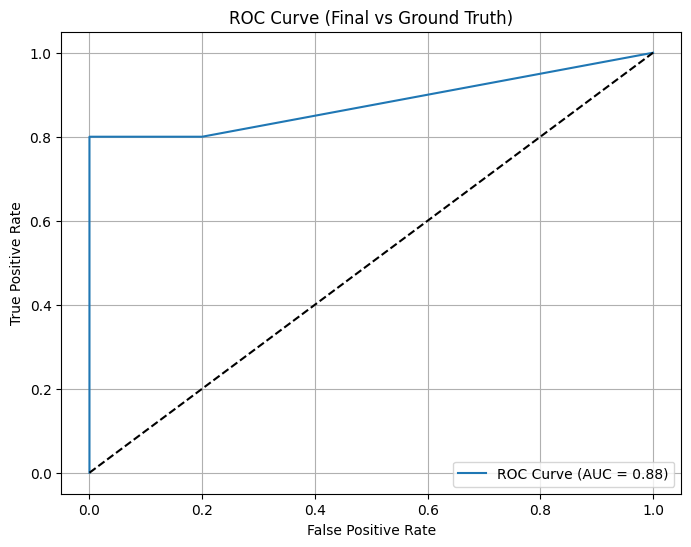

In [ ]:
# کد اضافه شده برای شمارش و ارزیابی
total_scenarios = len(initial_states)
same_count = 0
different_count = 0

# برای محاسبه معیارها (مانند Confusion Matrix برای دو کلاس: Stimulation=Positive, Monitoring/No_Action=Negative)
true_positives = 0  # Initial Stimulation و Final Stimulation
true_negatives = 0  # Initial Monitoring/No_Action و Final Monitoring/No_Action
false_positives = 0 # Initial Stimulation اما Final Monitoring/No_Action
false_negatives = 0 # Initial Monitoring/No_Action اما Final Stimulation

for i in range(total_scenarios):
    init = initial_states[i]
    fin = final_states[i]

    if init == fin:
        same_count += 1
        if init == 'Stimulation':
            true_positives += 1
        else:
            true_negatives += 1
    else:
        different_count += 1
        if init == 'Stimulation':
            false_positives += 1
        else:
            false_negatives += 1

# محاسبه Correction Rate
correction_rate = different_count / total_scenarios if total_scenarios > 0 else 0

# محاسبه معیارهای ارزیابی
accuracy_result = (true_positives + true_negatives) / total_scenarios if total_scenarios > 0 else 0
precision_result = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall_result = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_result = 2 * (precision_result * recall_result) / (precision_result + recall_result) if (precision_result + recall_result) > 0 else 0

print("\n================ Initial vs Final Evaluation Summary ================")
print(f"Total Scenarios: {total_scenarios}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are the SAME: {same_count}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: {different_count}")
print(f"Correction Rate: {correction_rate:.2f}")
print(f"Accuracy: {accuracy_result:.2f}")
print(f"Precision (for Stimulation): {precision_result:.2f}")
print(f"Recall (for Stimulation): {recall_result:.2f}")
print(f"F1-Score (for Stimulation): {f1_result:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Initial vs Final):")
print("                Predicted Stimulation | Predicted Monitoring/No_Action")
print(f"Actual Stimulation | {true_positives}                  | {false_negatives}")
print(f"Actual Monitoring/No_Action | {false_positives}                  | {true_negatives}")

# کد اضافه شده برای خواندن Ground_truth و ارزیابی بر اساس آن
def read_ground_truth(file_path):
    ground_truth = []
    with open(file_path, 'r') as f:
        for line in f:
            label = line.strip()
            ground_truth.append(label)
    return ground_truth

file_path_ground_truth = "Ground_truth.txt"  # نام فایل Ground_truth
ground_truth_labels = read_ground_truth(file_path_ground_truth)

if len(ground_truth_labels) != total_scenarios:
    print("تعداد خطوط Ground_truth با تعداد سناریوها همخوانی ندارد.")
else:
    # تبدیل برچسب‌ها به باینری برای ارزیابی
    y_true_ground = [1 if label == "Stimulation" else 0 for label in ground_truth_labels]
    y_pred_final = [1 if state == "Stimulation" else 0 for state in final_states]
    y_pred_initial = [1 if state == "Stimulation" else 0 for state in initial_states]

    # محاسبه معیارها برای Final vs Ground Truth
    accuracy_ground_val = accuracy_score(y_true_ground, y_pred_final)
    precision_ground_val = precision_score(y_true_ground, y_pred_final, zero_division=0)
    recall_ground_val = recall_score(y_true_ground, y_pred_final, zero_division=0)
    f1_ground_val = f1_score(y_true_ground, y_pred_final, zero_division=0)
    auc_ground_val = roc_auc_score(y_true_ground, defuzzified_scores)  # استفاده از defuzzified_scores به عنوان y_scores

    # Confusion Matrix برای Final vs Ground Truth
    true_positives_ground = 0
    true_negatives_ground = 0
    false_positives_ground = 0
    false_negatives_ground = 0

    for i in range(total_scenarios):
        true_label = ground_truth_labels[i]
        pred_label = final_states[i]

        if true_label == pred_label:
            if true_label == 'Stimulation':
                true_positives_ground += 1
            else:
                true_negatives_ground += 1
        else:
            if true_label == 'Stimulation':
                false_negatives_ground += 1
            else:
                false_positives_ground += 1

    print("\n================ Final vs Ground Truth Evaluation Summary ================")
    print(f"Accuracy (Final vs Ground Truth): {accuracy_ground_val:.2f}")
    print(f"Precision (Final vs Ground Truth): {precision_ground_val:.2f}")
    print(f"Recall (Final vs Ground Truth): {recall_ground_val:.2f}")
    print(f"F1-Score (Final vs Ground Truth): {f1_ground_val:.2f}")
    print(f"AUC (Final vs Ground Truth): {auc_ground_val:.2f}")

    # Confusion Matrix
    print("\nConfusion Matrix (Final vs Ground Truth):")
    print("                Predicted Stimulation | Predicted Monitoring/No_Action")
    print(f"Actual Stimulation | {true_positives_ground}                  | {false_negatives_ground}")
    print(f"Actual Monitoring/No_Action | {false_positives_ground}                  | {true_negatives_ground}")

    # ترسیم ROC Curve
    fpr, tpr, _ = roc_curve(y_true_ground, defuzzified_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_ground_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # خط تصادفی
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Final vs Ground Truth)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


================ Initial vs Final Evaluation Summary ================
Total Scenarios: 10
Number of scenarios where Initial and Final Sate_To_Body are the SAME: 3
Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: 7
TP: 0
TN: 3
FP: 0
FN: 7
Correction Rate (CR): 0.70
Accuracy: 0.30
Precision (for Stimulation): 0.00
Recall (for Stimulation): 0.00
F1-Score (for Stimulation): 0.00

Confusion Matrix (Initial vs Final):
                Predicted Stimulation | Predicted Monitoring/No_Action
Actual Stimulation | 0                  | 7
Actual Monitoring/No_Action | 0                  | 3

================ Final vs Ground Truth Evaluation Summary ================
TP: 5
TN: 3
FP: 2
FN: 0
Accuracy (Final vs Ground Truth): 0.80
Precision (Final vs Ground Truth): 0.71
Recall (Final vs Ground Truth): 1.00
F1-Score (Final vs Ground Truth): 0.83
AUC (Final vs Ground Truth): 0.88
Correction Rate (CR): 0.70
False-Correction Rate (FCR): 0.20
Correction Coverage (CC): 1.00
Interventio

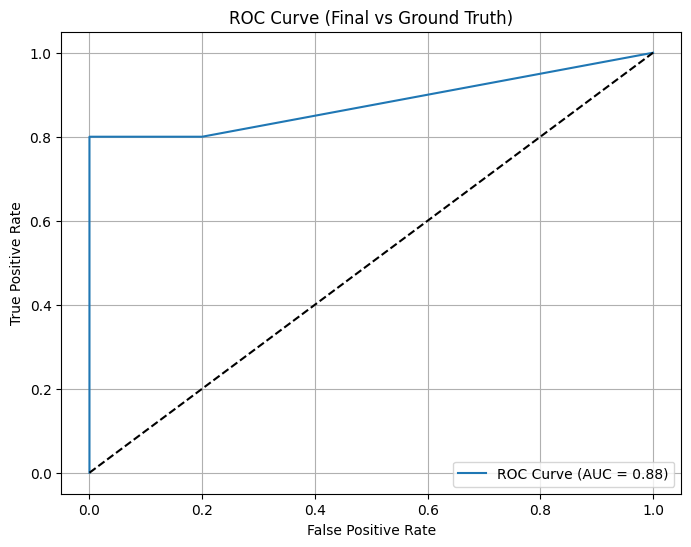

In [ ]:
# کد اضافه شده برای شمارش و ارزیابی
total_scenarios = len(initial_states)
same_count = 0
different_count = 0

# برای محاسبه معیارها (مانند Confusion Matrix برای دو کلاس: Stimulation=Positive, Monitoring/No_Action=Negative)
true_positives = 0  # Initial Stimulation و Final Stimulation
true_negatives = 0  # Initial Monitoring/No_Action و Final Monitoring/No_Action
false_positives = 0 # Initial Stimulation اما Final Monitoring/No_Action
false_negatives = 0 # Initial Monitoring/No_Action اما Final Stimulation

for i in range(total_scenarios):
    init = initial_states[i]
    fin = final_states[i]

    if init == fin:
        same_count += 1
        if init == 'Stimulation':
            true_positives += 1
        else:
            true_negatives += 1
    else:
        different_count += 1
        if init == 'Stimulation':
            false_positives += 1
        else:
            false_negatives += 1


# محاسبه Correction Rate (CR)
correction_rate = different_count / total_scenarios if total_scenarios > 0 else 0

# محاسبه معیارهای ارزیابی
accuracy_result = (true_positives + true_negatives) / total_scenarios if total_scenarios > 0 else 0
precision_result = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall_result = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_result = 2 * (precision_result * recall_result) / (precision_result + recall_result) if (precision_result + recall_result) > 0 else 0

print("\n================ Initial vs Final Evaluation Summary ================")
print(f"Total Scenarios: {total_scenarios}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are the SAME: {same_count}")
print(f"Number of scenarios where Initial and Final Sate_To_Body are DIFFERENT: {different_count}")
print(f"TP: {true_positives}")
print(f"TN: {true_negatives}")
print(f"FP: {false_positives}")
print(f"FN: {false_negatives}")
print(f"Correction Rate (CR): {correction_rate:.2f}")
print(f"Accuracy: {accuracy_result:.2f}")
print(f"Precision (for Stimulation): {precision_result:.2f}")
print(f"Recall (for Stimulation): {recall_result:.2f}")
print(f"F1-Score (for Stimulation): {f1_result:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Initial vs Final):")
print("                Predicted Stimulation | Predicted Monitoring/No_Action")
print(f"Actual Stimulation | {true_positives}                  | {false_negatives}")
print(f"Actual Monitoring/No_Action | {false_positives}                  | {true_negatives}")

# کد اضافه شده برای خواندن Ground_truth و ارزیابی بر اساس آن
def read_ground_truth(file_path):
    ground_truth = []
    with open(file_path, 'r') as f:
        for line in f:
            label = line.strip()
            ground_truth.append(label)
    return ground_truth

file_path_ground_truth = "Ground_truth.txt"  # نام فایل Ground_truth
ground_truth_labels = read_ground_truth(file_path_ground_truth)

if len(ground_truth_labels) != total_scenarios:
    print("تعداد خطوط Ground_truth با تعداد سناریوها همخوانی ندارد.")
else:
    # تبدیل برچسب‌ها به باینری برای ارزیابی
    y_true_ground = [1 if label == "Stimulation" else 0 for label in ground_truth_labels]
    y_pred_final = [1 if state == "Stimulation" else 0 for state in final_states]
    y_pred_initial = [1 if state == "Stimulation" else 0 for state in initial_states]

    # محاسبه معیارها برای Final vs Ground Truth
    accuracy_ground_val = accuracy_score(y_true_ground, y_pred_final)
    precision_ground_val = precision_score(y_true_ground, y_pred_final, zero_division=0)
    recall_ground_val = recall_score(y_true_ground, y_pred_final, zero_division=0)
    f1_ground_val = f1_score(y_true_ground, y_pred_final, zero_division=0)
    auc_ground_val = roc_auc_score(y_true_ground, defuzzified_scores)  # استفاده از defuzzified_scores به عنوان y_scores

    # محاسبه معیارهای جدید
    false_corrections = 0  # تعداد تغییرات نادرست (initial = ground truth اما final ≠ ground truth)
    successful_corrections = 0  # تعداد اصلاحات موفق (initial ≠ ground truth و final = ground truth)
    interventions = 0  # تعداد سناریوهای با Final Sate_To_Body = Stimulation
    different_count_ground = 0  # تعداد سناریوهایی که initial با final متفاوت است

    for i in range(total_scenarios):
        initial = initial_states[i]
        final = final_states[i]
        true_label = ground_truth_labels[i]

        # محاسبه Correction Rate (CR) برای Ground Truth
        if initial != final:
            different_count_ground += 1

        # محاسبه False-Correction Rate (FCR)
        if initial == true_label and final != true_label:
            false_corrections += 1

        # محاسبه Correction Coverage (CC)
        if initial != true_label and final == true_label:
            successful_corrections += 1

        # محاسبه Intervention Rate (IR)
        if final == 'Stimulation':
            interventions += 1

    # تعداد سناریوهای نیازمند اصلاح (initial ≠ ground truth)
    needing_correction = sum(1 for i in range(total_scenarios) if initial_states[i] != ground_truth_labels[i])

    # محاسبه معیارها
    correction_rate_ground = different_count_ground / total_scenarios if total_scenarios > 0 else 0
    false_correction_rate = false_corrections / total_scenarios if total_scenarios > 0 else 0
    correction_coverage = successful_corrections / needing_correction if needing_correction > 0 else 0
    intervention_rate = interventions / total_scenarios if total_scenarios > 0 else 0

    # Confusion Matrix برای Final vs Ground Truth
    true_positives_ground = 0
    true_negatives_ground = 0
    false_positives_ground = 0
    false_negatives_ground = 0

    for i in range(total_scenarios):
        true_label = ground_truth_labels[i]
        pred_label = final_states[i]

        if true_label == pred_label:
            if true_label == 'Stimulation':
                true_positives_ground += 1
            else:
                true_negatives_ground += 1
        else:
            if true_label == 'Stimulation':
                false_negatives_ground += 1
            else:
                false_positives_ground += 1

    print("\n================ Final vs Ground Truth Evaluation Summary ================")
    print(f"TP: {true_positives_ground}")
    print(f"TN: {true_negatives_ground}")
    print(f"FP: {false_positives_ground}")
    print(f"FN: {false_negatives_ground}")
    print(f"Accuracy (Final vs Ground Truth): {accuracy_ground_val:.2f}")
    print(f"Precision (Final vs Ground Truth): {precision_ground_val:.2f}")
    print(f"Recall (Final vs Ground Truth): {recall_ground_val:.2f}")
    print(f"F1-Score (Final vs Ground Truth): {f1_ground_val:.2f}")
    print(f"AUC (Final vs Ground Truth): {auc_ground_val:.2f}")
    print(f"Correction Rate (CR): {correction_rate_ground:.2f}")
    print(f"False-Correction Rate (FCR): {false_correction_rate:.2f}")
    print(f"Correction Coverage (CC): {correction_coverage:.2f}")
    print(f"Intervention Rate (IR): {intervention_rate:.2f}")

    # Confusion Matrix
    print("\nConfusion Matrix (Final vs Ground Truth):")
    print("                Predicted Stimulation | Predicted Monitoring/No_Action")
    print(f"Actual Stimulation | {true_positives_ground}                  | {false_negatives_ground}")
    print(f"Actual Monitoring/No_Action | {false_positives_ground}                  | {true_negatives_ground}")

    # ترسیم ROC Curve
    fpr, tpr, _ = roc_curve(y_true_ground, defuzzified_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_ground_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # خط تصادفی
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Final vs Ground Truth)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()